# Extracting MET4A Pickle Data

All the code is in the met4a package, so we can import it here

In [1]:
from met4a import *

We can use the load_pickle function to load the data of a single pickle file into a dictionary

In [2]:
path = "/workspaces/met4a_data/2026_02_12/1770931655.952085.met4a.pkl"
data_dict = load_pickle(path)

data_dict.keys()

dict_keys(['start_time', 'ref_pressure', 'scale_fac', 'nsamp', 'times', 'pressure', 'temp', 'rh'])

We can also use the load_all_pickles function to load all pickle files in a directory into a list of dictionaries

In [3]:
directory = "/workspaces/met4a_data/2026_02_12/"
data_list = load_all_pickles(directory)
print(len(data_list))
data_list[0].keys()

449


dict_keys(['start_time', 'ref_pressure', 'scale_fac', 'nsamp', 'times', 'pressure', 'temp', 'rh'])

The function dict_to_df can be used to convert a dictionary into a pandas DataFrame

In [4]:
df = dict_to_df(data_dict)
df.head()

,start_time,ref_pressure,scale_fac,nsamp,times,pressure,temp,rh
0,1.770932e+09,40.059721,64.0,1000,0.030186,0.000012,4.39,71.8
1,1.770932e+09,40.059721,64.0,1000,0.045316,-0.000017,4.39,71.8
2,1.770932e+09,40.059721,64.0,1000,0.061831,-0.000003,4.39,71.8
3,1.770932e+09,40.059721,64.0,1000,0.078272,-0.000008,4.39,71.8
4,1.770932e+09,40.059721,64.0,1000,0.093379,-0.000056,4.39,71.8


To quickly convert all dictionaries in the list to DataFrames, we can use a list comprehension

In [ ]:
df_list = [dict_to_df(d) for d in data_list]
print(len(df_list))
df_list[0].head()

449


,start_time,ref_pressure,scale_fac,nsamp,times,pressure,temp,rh
0,1.770932e+09,40.059721,64.0,1000,0.030186,0.000012,4.39,71.8
1,1.770932e+09,40.059721,64.0,1000,0.045316,-0.000017,4.39,71.8
2,1.770932e+09,40.059721,64.0,1000,0.061831,-0.000003,4.39,71.8
3,1.770932e+09,40.059721,64.0,1000,0.078272,-0.000008,4.39,71.8
4,1.770932e+09,40.059721,64.0,1000,0.093379,-0.000056,4.39,71.8


## Coalescing Data Samples

We can coalesce many data samples into one large list of samples

In [1]:
from met4a import *

directory_path = "/workspaces/met4a_data/2026_02_12"
data_list = load_all_pickles(directory_path)

time, pressure = coalesce_time_pressure(data_list)

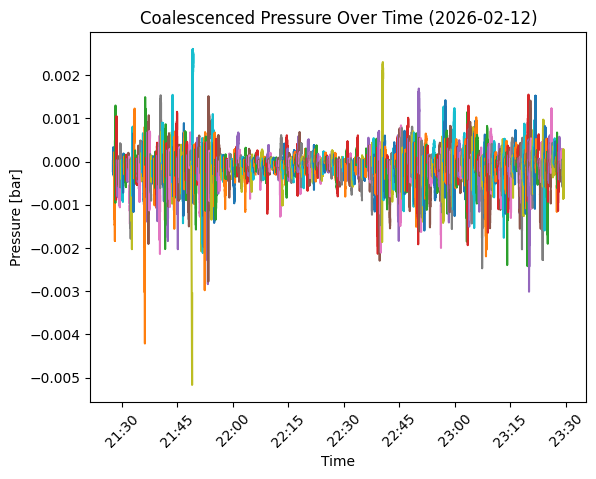

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots()

for idx in range(len(time)):
    ax.plot(time[idx], pressure[idx])

date_str = time[0][0].strftime('%Y-%m-%d')
plt.title(f"Coalescenced Pressure Over Time ({date_str})")
plt.xlabel("Time")
plt.ylabel("Pressure [bar]")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45);

We can also concatenate them to make on large sample array. The `time` array is now in `np.datetime64`

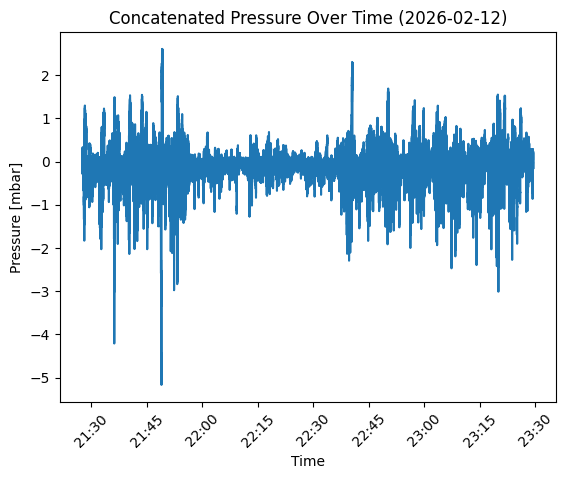

In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

time, pressure = coalesce_time_pressure(data_list, concatenate=True)

pressure = pressure*1000 # Convert from bar to mbar

fig, ax = plt.subplots()

ax.plot(time, pressure)

date_str = time[0].astype('datetime64[ms]').item().strftime('%Y-%m-%d')
plt.title(f"Concatenated Pressure Over Time ({date_str})")
plt.xlabel("Time")
plt.ylabel("Pressure [mbar]")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45);

In [ ]:
import re
from pathlib import Path
from datetime import datetime, timezone

import numpy as np

# Parsing expected line: "*156592,+39.924365,+12.45,+044.2,0"
LINE_RE = re.compile(
    r"^\*(\d+),([+-]?\d+\.\d+),([+-]?\d+\.\d+),([+-]?\d+\.\d+),(-?\d+)$"
)

DTYPE = np.dtype([
    ("sample", "i8"),
    ("raw_time", "i8"),
    ("epoch_time", "f8"),
    ("pressure", "f8"),
    ("temp", "f8"),
    ("rh", "f8"),
    ("status", "i4"),
])


def read_met4a_raw(path, start_time=None, sample_rate_hz=1.0):
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for sample, line in enumerate(f):
            line = line.strip()
            if not line:
                continue

            m = LINE_RE.match(line)
            if not m:
                raise ValueError(f"Bad raw line {sample + 1}: {line!r}")

            raw_time = int(m.group(1))
            pressure = float(m.group(2))
            temp = float(m.group(3))
            rh = float(m.group(4))
            status = int(m.group(5))

            if start_time is None:
                epoch_time = np.nan
            else:
                # safest default if raw_time is not a real Unix epoch:
                # reconstruct time from sample index
                epoch_time = start_time + sample / sample_rate_hz

            rows.append((sample, raw_time, epoch_time, pressure, temp, rh, status))

    return np.array(rows, dtype=DTYPE).view(np.recarray)


if __name__ == "__main__":
    raw_path = "../2026_03_22/raw_data.txt"

    # Use this if you know the start_time from the pickle or filename.
    start_time = 1770931655.952085

    data = read_met4a_raw(
        raw_path,
        start_time=start_time,
        sample_rate_hz=1.0,
    )

    print(data[:5])
    print("First epoch:", data.epoch_time[0])
    print("First datetime:", datetime.fromtimestamp(data.epoch_time[0], tz=timezone.utc))

[(0, 156592, 1.77093166e+09, 39.924365, 12.45, 44.2, 0)
 (1, 156592, 1.77093166e+09, 39.9243  , 12.44, 44.2, 0)
 (2, 156592, 1.77093166e+09, 39.924276, 12.44, 44.2, 0)
 (3, 156592, 1.77093166e+09, 39.924326, 12.44, 44.2, 0)
 (4, 156592, 1.77093166e+09, 39.924364, 12.44, 44.2, 0)]
First epoch: 1770931655.952085
First datetime: 2026-02-12 21:27:35.952085+00:00
